In [63]:
import pandas as pd

In [64]:
d = pd.read_excel("instruments.xlsx")
d.head()

,Instrument_ID,Record_Date,Instrument_Self life,Incidents_Last_365_Days,Environmental Issue,Corrosive/Sticky Material,Days_Since_Last_PM,Usage_Hours_Since_PM,PM_Overdue,OOS_Linked_Last_180_Days,Calibration_Failed_Recently,Analyst_Experience_Level (1-5),First_Batch_After_Maintenance,Issue_Occurred_Next_30_Days
0,HPLC_01,2026-01-01,47,3,0,1,20,110,0,0,0,3,0,0
1,HPLC_02,2026-01-01,117,0,0,0,95,380,1,1,1,1,1,1
2,GC_01,2026-01-01,67,0,1,0,40,150,0,0,0,2,0,0
3,HPLC_03,2026-02-01,103,0,0,1,60,250,0,0,0,2,0,0
4,GC_02,2026-02-01,9,5,0,1,120,420,1,2,1,1,1,1


In [72]:
data = d.drop(columns=["Instrument_ID", "Record_Date"])
data = data.apply(pd.to_numeric, errors='coerce')
data.head()

,Instrument_Self life,Incidents_Last_365_Days,Environmental Issue,Corrosive/Sticky Material,Days_Since_Last_PM,Usage_Hours_Since_PM,PM_Overdue,OOS_Linked_Last_180_Days,Calibration_Failed_Recently,Analyst_Experience_Level (1-5),First_Batch_After_Maintenance,Issue_Occurred_Next_30_Days
0,47,3,0,1,20,110,0,0,0,3,0,0
1,117,0,0,0,95,380,1,1,1,1,1,1
2,67,0,1,0,40,150,0,0,0,2,0,0
3,103,0,0,1,60,250,0,0,0,2,0,0
4,9,5,0,1,120,420,1,2,1,1,1,1


In [73]:
x = data.drop("Issue_Occurred_Next_30_Days", axis=1)
y = data["Issue_Occurred_Next_30_Days"]

In [74]:
data.head()

,Instrument_Self life,Incidents_Last_365_Days,Environmental Issue,Corrosive/Sticky Material,Days_Since_Last_PM,Usage_Hours_Since_PM,PM_Overdue,OOS_Linked_Last_180_Days,Calibration_Failed_Recently,Analyst_Experience_Level (1-5),First_Batch_After_Maintenance,Issue_Occurred_Next_30_Days
0,47,3,0,1,20,110,0,0,0,3,0,0
1,117,0,0,0,95,380,1,1,1,1,1,1
2,67,0,1,0,40,150,0,0,0,2,0,0
3,103,0,0,1,60,250,0,0,0,2,0,0
4,9,5,0,1,120,420,1,2,1,1,1,1


In [76]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [77]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [78]:
accuracy = model.score(x_test, y_test)
print("Model Accuracy: ", accuracy)

Model Accuracy:  0.5666666666666667


In [71]:
print(x.columns)

Index(['Instrument_Self life', 'Incidents_Last_365_Days',
       'Environmental Issue', 'Corrosive/Sticky Material',
       'Days_Since_Last_PM', 'Usage_Hours_Since_PM', 'PM_Overdue',
       'OOS_Linked_Last_180_Days', 'Calibration_Failed_Recently',
       'Analyst_Experience_Level (1-5)', 'First_Batch_After_Maintenance'],
      dtype='object')


In [61]:
from sklearn.metrics import classification_report

y_pred = model.predict(x_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.50      0.23      0.32        13
           1       0.58      0.82      0.68        17

    accuracy                           0.57        30
   macro avg       0.54      0.53      0.50        30
weighted avg       0.55      0.57      0.52        30



In [62]:
print(y.value_counts())

Issue_Occurred_Next_30_Days
1    93
0    57
Name: count, dtype: int64


In [40]:
sample = x_test.iloc[[0]]  # take one example
 
risk_prob = model.predict_proba(sample)[0][1]  # probability of class 1 (issue)
health_score = int((1 - risk_prob) * 100)
 
print("Risk Probability:", round(risk_prob, 2))
print("Instrument Health Score:", health_score, "/ 100")

Risk Probability: 0.82
Instrument Health Score: 18 / 100


In [41]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index = x.columns)
print(feature_importance.sort_values(ascending = False))

OOS_Linked_Last_180_Days          0.209541
Days_Since_Last_PM                0.170735
Usage_Hours_Since_PM              0.149111
Instrument_Self life              0.144333
Incidents_Last_365_Days           0.078786
Calibration_Failed_Recently       0.071245
Analyst_Experience_Level (1-5)    0.060622
PM_Overdue                        0.046411
Corrosive/Sticky Material         0.023730
Environmental Issue               0.022849
First_Batch_After_Maintenance     0.022637
dtype: float64


In [42]:
risk_probs = model.predict_proba(x)[:, 1]
health_scores = (1 - risk_probs) * 100
 
df_results = data.copy()
df_results["Risk_Probability"] = risk_probs
df_results["Health_Score"] = health_scores.astype(int)
 
df_results.head()

,Instrument_Self life,Incidents_Last_365_Days,Environmental Issue,Corrosive/Sticky Material,Days_Since_Last_PM,Usage_Hours_Since_PM,PM_Overdue,OOS_Linked_Last_180_Days,Calibration_Failed_Recently,Analyst_Experience_Level (1-5),First_Batch_After_Maintenance,Issue_Occurred_Next_30_Days,Risk_Probability,Health_Score
0,47,3,0,1,20,110,0,0,0,3,0,0,0.09,91
1,117,0,0,0,95,380,1,1,1,1,1,1,0.87,13
2,67,0,1,0,40,150,0,0,0,2,0,0,0.02,98
3,103,0,0,1,60,250,0,0,0,2,0,0,0.04,96
4,9,5,0,1,120,420,1,2,1,1,1,1,0.93,6


In [79]:
y.value_counts()

Issue_Occurred_Next_30_Days
1    93
0    57
Name: count, dtype: int64

In [81]:
x.dtypes

Instrument_Self life              int64
Incidents_Last_365_Days           int64
Environmental Issue               int64
Corrosive/Sticky Material         int64
Days_Since_Last_PM                int64
Usage_Hours_Since_PM              int64
PM_Overdue                        int64
OOS_Linked_Last_180_Days          int64
Calibration_Failed_Recently       int64
Analyst_Experience_Level (1-5)    int64
First_Batch_After_Maintenance     int64
dtype: object

In [82]:
x.isna().sum()

Instrument_Self life              0
Incidents_Last_365_Days           0
Environmental Issue               0
Corrosive/Sticky Material         0
Days_Since_Last_PM                0
Usage_Hours_Since_PM              0
PM_Overdue                        0
OOS_Linked_Last_180_Days          0
Calibration_Failed_Recently       0
Analyst_Experience_Level (1-5)    0
First_Batch_After_Maintenance     0
dtype: int64

In [83]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

X = x   # your features
y = y   # your target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

dummy = DummyClassifier(strategy="most_frequent")  # always predicts the majority class (1)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("Baseline (always predict 1) accuracy:", accuracy_score(y_test, y_pred_dummy))
print(classification_report(y_test, y_pred_dummy))

Baseline (always predict 1) accuracy: 0.6333333333333333
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        11
           1       0.63      1.00      0.78        19

    accuracy                           0.63        30
   macro avg       0.32      0.50      0.39        30
weighted avg       0.40      0.63      0.49        30



C:\Users\SL455DM\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SL455DM\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\SL455DM\AppData\Local\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is

In [84]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

rf = RandomForestClassifier(
    n_estimators=400,
    random_state=42,
    class_weight="balanced"  # helps with the 62/38 imbalance
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("RF accuracy:", accuracy_score(y_test, y_pred))
print("RF ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

RF accuracy: 0.8
RF ROC-AUC: 0.9138755980861243
              precision    recall  f1-score   support

           0       0.86      0.55      0.67        11
           1       0.78      0.95      0.86        19

    accuracy                           0.80        30
   macro avg       0.82      0.75      0.76        30
weighted avg       0.81      0.80      0.79        30



In [85]:
import numpy as np
from sklearn.metrics import f1_score, classification_report

best_t, best_f1 = 0.5, 0
for t in np.linspace(0.1, 0.9, 81):
    y_hat = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_hat)
    if f1 > best_f1:
        best_f1, best_t = f1, t

print(f"Best threshold: {best_t:.2f}, Best F1: {best_f1:.3f}")

# Evaluate at the tuned threshold
y_hat = (y_proba >= best_t).astype(int)
print(classification_report(y_test, y_hat))

Best threshold: 0.59, Best F1: 0.895
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        11
           1       0.89      0.89      0.89        19

    accuracy                           0.87        30
   macro avg       0.86      0.86      0.86        30
weighted avg       0.87      0.87      0.87        30



In [88]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(rf, X, y, cv=skf, scoring="roc_auc")
cv_f1  = cross_val_score(rf, X, y, cv=skf, scoring="f1")

print(f"CV ROC-AUC: {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"CV F1:      {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")

CV ROC-AUC: 0.771 ± 0.084
CV F1:      0.783 ± 0.045


In [89]:
BEST_THRESHOLD = 0.59

y_proba = rf.predict_proba(X_test)[:, 1]
y_hat   = (y_proba >= BEST_THRESHOLD).astype(int)

In [92]:
import joblib
joblib.dump({"model": rf, "threshold": BEST_THRESHOLD, "feature_names": X.columns.tolist()}, "issue_model_rf.pkl")

['issue_model_rf.pkl']

In [93]:
bundle = joblib.load("issue_model_rf.pkl")
rf = bundle["model"]
BEST_THRESHOLD = bundle["threshold"]
feature_names = bundle["feature_names"]

In [94]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import roc_auc_score, f1_score

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
proba_cv = cross_val_predict(rf, X, y, cv=skf, method="predict_proba")[:, 1]
print("CV ROC-AUC:", roc_auc_score(y, proba_cv))

# Optional: pick a global threshold from CV probs
import numpy as np
ts = np.linspace(0.1, 0.9, 81)
f1s = [f1_score(y, (proba_cv >= t).astype(int)) for t in ts]
t_cv = ts[int(np.argmax(f1s))]
print("CV-chosen threshold:", t_cv)

CV ROC-AUC: 0.7593850216940201
CV-chosen threshold: 0.44000000000000006


In [95]:
import pandas as pd
fi = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(fi)

Days_Since_Last_PM                0.184456
Usage_Hours_Since_PM              0.150329
OOS_Linked_Last_180_Days          0.141432
Instrument_Self life              0.138211
Calibration_Failed_Recently       0.105185
Analyst_Experience_Level (1-5)    0.074947
Incidents_Last_365_Days           0.070346
PM_Overdue                        0.054664
Corrosive/Sticky Material         0.030369
First_Batch_After_Maintenance     0.027649
Environmental Issue               0.022412
dtype: float64


In [107]:
import joblib

bundle = joblib.load("issue_model_rf.pkl")
rf = bundle["model"]
BEST_THRESHOLD = bundle["threshold"]        # if your bundle has this
feature_names = bundle["feature_names"]     # list of 11 feature columns

print("Loaded. Threshold:", BEST_THRESHOLD)
print("Features:", feature_names)

Loaded. Threshold: 0.59
Features: ['Instrument_Self life', 'Incidents_Last_365_Days', 'Environmental Issue', 'Corrosive/Sticky Material', 'Days_Since_Last_PM', 'Usage_Hours_Since_PM', 'PM_Overdue', 'OOS_Linked_Last_180_Days', 'Calibration_Failed_Recently', 'Analyst_Experience_Level (1-5)', 'First_Batch_After_Maintenance']


In [108]:
import pandas as pd

df_new = pd.read_excel("instruments.xlsx", engine="openpyxl")

# Check columns
print("Columns in Excel:", df_new.columns.tolist())

# Ensure required features exist (create missing ones as 0)
missing = [c for c in feature_names if c not in df_new.columns]
if missing:
    print("Adding missing columns with 0:", missing)
    for c in missing:
        df_new[c] = 0

# Build X in the correct order and ensure numeric
X_new = df_new[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0)

Columns in Excel: ['Instrument_ID', 'Record_Date', 'Instrument_Self life', 'Incidents_Last_365_Days', 'Environmental Issue', 'Corrosive/Sticky Material', 'Days_Since_Last_PM', 'Usage_Hours_Since_PM', 'PM_Overdue', 'OOS_Linked_Last_180_Days', 'Calibration_Failed_Recently', 'Analyst_Experience_Level (1-5)', 'First_Batch_After_Maintenance', 'Issue_Occurred_Next_30_Days']


In [109]:
import numpy as np

y_proba = rf.predict_proba(X_new)[:, 1]
y_pred  = (y_proba >= BEST_THRESHOLD).astype(int)

# Attach to your original data (keeps any ID/Date columns for traceability)
df_out = df_new.copy()
df_out["Predicted_Probability"] = y_proba
df_out["Predicted_Class"] = y_pred

# See some results on screen
print(df_out.head(10))
print("Prediction counts:")
print(df_out["Predicted_Class"].value_counts())

  Instrument_ID Record_Date  Instrument_Self life  Incidents_Last_365_Days  \
0       HPLC_01  2026-01-01                    47                        3   
1       HPLC_02  2026-01-01                   117                        0   
2         GC_01  2026-01-01                    67                        0   
3       HPLC_03  2026-02-01                   103                        0   
4         GC_02  2026-02-01                     9                        5   
5         GC_01  2025-01-01                    21                        5   
6       HPLC_01  2025-01-08                    36                        1   
7       HPLC_02  2025-01-15                    87                        0   
8       HPLC_03  2025-01-22                    70                        4   
9         GC_01  2025-01-29                    88                        1   

   Environmental Issue  Corrosive/Sticky Material  Days_Since_Last_PM  \
0                    0                          1                  2

In [110]:
out_path = "instrument_predictions.xlsx"
df_out.to_excel(out_path, index=False)
print("Saved:", out_path)

Saved: instrument_predictions.xlsx


In [111]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

target_col = "Issue_Occurred_Next_30_Days"
if target_col in df_new.columns:
    y_eval = pd.to_numeric(df_new[target_col], errors="coerce").fillna(0).astype(int)

    print("ROC-AUC:", roc_auc_score(y_eval, y_proba))
    print(classification_report(y_eval, y_pred))

    cm = confusion_matrix(y_eval, y_pred)
    print("Confusion Matrix:\n", cm)
else:
    cm = None
    print("No target column found—skipping evaluation.")

ROC-AUC: 0.9959441614789663
              precision    recall  f1-score   support

           0       0.96      0.96      0.96        57
           1       0.98      0.98      0.98        93

    accuracy                           0.97       150
   macro avg       0.97      0.97      0.97       150
weighted avg       0.97      0.97      0.97       150

Confusion Matrix:
 [[55  2]
 [ 2 91]]


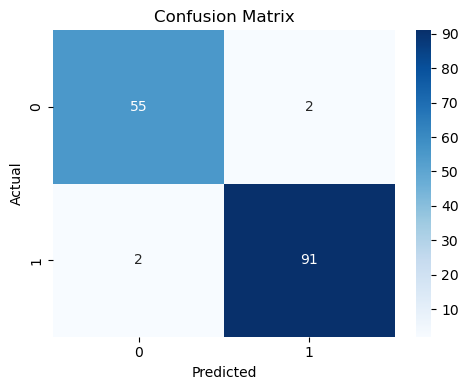

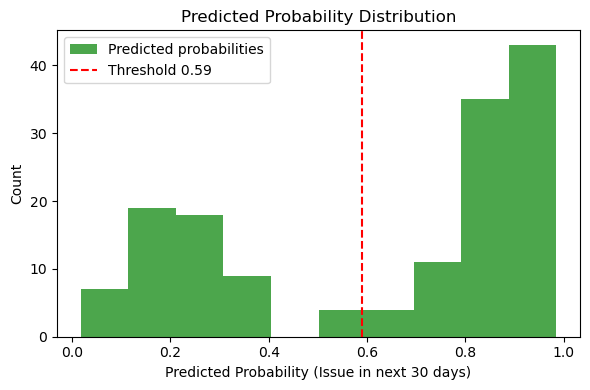

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion Matrix chart (only if cm exists)
if cm is not None:
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=200)
    plt.show()

# Probability Distribution chart (works even without labels)
plt.figure(figsize=(6,4))
plt.hist(y_proba, bins=10, color="green", alpha=0.7, label="Predicted probabilities")
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Threshold {BEST_THRESHOLD:.2f}")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability (Issue in next 30 days)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.savefig("probability_distribution.png", dpi=200)
plt.show()

In [119]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# ---------------- 1) Load saved model bundle ----------------
bundle = joblib.load("issue_model_rf.pkl")  # must be in the same folder

rf = bundle["model"]
BEST_THRESHOLD = bundle.get("threshold", 0.44)  # fallback to 0.44 if not present in bundle
feature_names = bundle.get("feature_names", [
    "Instrument_Self life",
    "Incidents_Last_365_Days",
    "Environmental Issue",
    "Corrosive/Sticky Material",
    "Days_Since_Last_PM",
    "Usage_Hours_Since_PM",
    "PM_Overdue",
    "OOS_Linked_Last_180_Days",
    "Calibration_Failed_Recently",
    "Analyst_Experience_Level (1-5)",
    "First_Batch_After_Maintenance"
])

print("Loaded model. Threshold =", BEST_THRESHOLD)
print("Expecting features:", feature_names)

# ---------------- 2) Load Excel ----------------
excel_path = "instrument_data.xlsx"  # change if needed
df = pd.read_excel(excel_path, engine="openpyxl")
print("Read Excel with columns:", df.columns.tolist())
print("Rows:", len(df))

# ---------------- 3) Prepare features (auto-fix missing cols) ----------------
missing = [c for c in feature_names if c not in df.columns]
if missing:
    print("Adding missing feature columns (filled with 0):", missing)
    for c in missing:
        df[c] = 0

X = df[feature_names].apply(pd.to_numeric, errors="coerce").fillna(0)

# ---------------- 4) Detect labels (optional) ----------------
target_col = "Issue_Occurred_Next_30_Days"
has_labels = target_col in df.columns

if has_labels:
    from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
    y_eval = pd.to_numeric(df[target_col], errors="coerce").fillna(0).astype(int)
    print(f"Detected labels in '{target_col}'. Will compute metrics.")
else:
    y_eval = None
    print(f"No '{target_col}' column found. Will skip metrics and confusion matrix.")

# ---------------- 5) Predict ----------------
y_proba = rf.predict_proba(X)[:, 1]
y_pred = (y_proba >= BEST_THRESHOLD).astype(int)

# Attach predictions to original DataFrame and save
df_out = df.copy()
df_out["Predicted_Probability"] = y_proba
df_out["Predicted_Class"] = y_pred

out_xlsx = "instrument_predictions.xlsx"
df_out.to_excel(out_xlsx, index=False)
print("Saved predictions to:", out_xlsx)

# Show something in the console
print("\nPreview:")
print(df_out.head(10)[feature_names + ["Predicted_Probability", "Predicted_Class"]])
print("\nPrediction counts:\n", df_out["Predicted_Class"].value_counts())

# ---------------- 6) Charts (PNG) ----------------
# 6a) Probability distribution
plt.figure(figsize=(6,4))
plt.hist(y_proba, bins=10, color="green", alpha=0.7)
plt.axvline(BEST_THRESHOLD, color="red", linestyle="--", label=f"Threshold {BEST_THRESHOLD:.2f}")
plt.title("Predicted Probability Distribution")
plt.xlabel("Predicted Probability (Issue in next 30 days)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
prob_png = "probability_distribution.png"
plt.savefig(prob_png, dpi=200)
plt.close()
print("Saved:", prob_png)

# 6b) Confusion matrix (only if labels exist)
cm_png = None
if has_labels:
    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(5,4))
    # Plot simple matrix without seaborn (no extra installs)
    plt.imshow(cm, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    # Annotate counts
    for (i, j), v in np.ndenumerate(cm):
        plt.text(j, i, str(v), ha="center", va="center", color="black", fontsize=12)
    plt.xticks([0,1], ["0", "1"])
    plt.yticks([0,1], ["0", "1"])
    plt.colorbar(shrink=0.8)
    plt.tight_layout()
    cm_png = "confusion_matrix.png"
    plt.savefig(cm_png, dpi=200)
    plt.close()
    print("Saved:", cm_png)

# ---------------- 7) PDF report with Matplotlib (no extra installs) ----------------
pdf_path = "Model_Summary.pdf"
from matplotlib.backends.backend_pdf import PdfPages
with PdfPages(pdf_path) as pdf:
    # Summary page
    fig = plt.figure(figsize=(8.27, 11.69))  # A4 portrait
    plt.axis('off')
    lines = [
        "Instrument Issue Prediction – Summary",
        "",
        f"Model: RandomForestClassifier (balanced)",
        f"Threshold used: {BEST_THRESHOLD:.2f}",
        f"Total rows scored: {len(y_pred)}",
        f"Predicted 1s: {(y_pred==1).sum()} | Predicted 0s: {(y_pred==0).sum()}",
    ]
    if has_labels:
        roc = roc_auc_score(y_eval, y_proba)
        lines.append(f"ROC-AUC (this file): {roc:.3f}")
    y0 = 0.9
    for i, text in enumerate(lines):
        plt.text(0.1, y0 - i*0.04, text, fontsize=12, va='top')
    pdf.savefig(fig); plt.close(fig)

    # Confusion Matrix page (if any)
    if has_labels and cm_png and os.path.exists(cm_png):
        img = plt.imread(cm_png)
        fig = plt.figure(figsize=(8.27, 11.69))
        plt.axis('off')
        plt.title("Confusion Matrix", fontsize=14)
        plt.imshow(img); plt.axis('off')
        pdf.savefig(fig); plt.close(fig)

    # Probability Distribution page
    if os.path.exists(prob_png):
        img = plt.imread(prob_png)
        fig = plt.figure(figsize=(8.27, 11.69))
        plt.axis('off')
        plt.title("Predicted Probability Distribution", fontsize=14)
        plt.imshow(img); plt.axis('off')
        pdf.savefig(fig); plt.close(fig)

print("Saved PDF:", pdf_path)

Loaded model. Threshold = 0.59
Expecting features: ['Instrument_Self life', 'Incidents_Last_365_Days', 'Environmental Issue', 'Corrosive/Sticky Material', 'Days_Since_Last_PM', 'Usage_Hours_Since_PM', 'PM_Overdue', 'OOS_Linked_Last_180_Days', 'Calibration_Failed_Recently', 'Analyst_Experience_Level (1-5)', 'First_Batch_After_Maintenance']
Read Excel with columns: ['Instrument_ID', 'Record_Date', 'Days_Since_Last_PM', 'Usage_Hours_Since_PM', 'PM_Overdue', 'Incidents_Last_90_Days', 'OOS_Linked_Last_180_Days', 'Calibration_Failed_Recently', 'Method_Stress_Level', 'Environment_Issues', 'Analyst_Experience_Level', 'First_Batch_After_Maintenance', 'Issue_Occurred_Next_30_Days', 'Training Completed']
Rows: 125
Adding missing feature columns (filled with 0): ['Instrument_Self life', 'Incidents_Last_365_Days', 'Environmental Issue', 'Corrosive/Sticky Material', 'Analyst_Experience_Level (1-5)']
Detected labels in 'Issue_Occurred_Next_30_Days'. Will compute metrics.
Saved predictions to: instrum